# Module 2 | Class 3 Assignment: Data Visualization and Trend Analysis
**Dataset:** superstore_cleaned.csv  
**Libraries:** pandas, matplotlib, seaborn

In [9]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
df = pd.read_csv('/superstore_cleaned.csv')

# Convert Order Date column to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Quick overview of the dataset
print('Dataset shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Dataset shape: (10296, 21)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


---
## Task 1: Distribution Plots

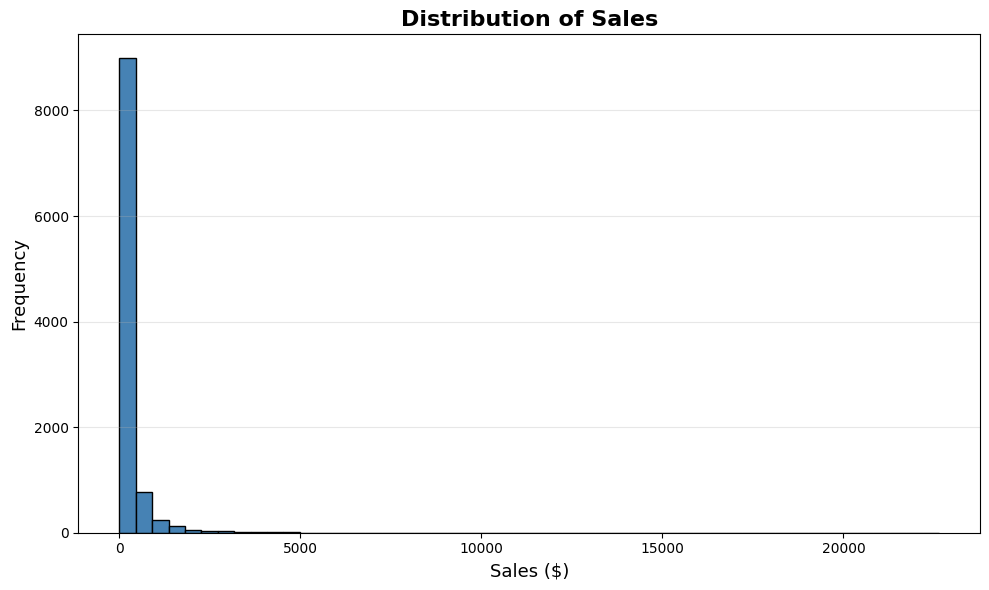

In [10]:
# --- Sales Histogram ---
# Shows how sales values are distributed across all transactions
plt.figure(figsize=(10, 6))
plt.hist(df['Sales'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Sales', fontsize=16, fontweight='bold')
plt.xlabel('Sales ($)', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis (Sales Histogram):**  
The Sales distribution is clearly right-skewed, meaning the majority of transactions involve relatively small amounts, while a few very large sales pull the tail to the right. This is typical in retail data where most customers purchase low-cost everyday items, but occasional corporate or bulk orders create extreme high-value transactions. As a result, the mean is significantly higher than the median, making the median a more reliable measure of central tendency for this dataset.

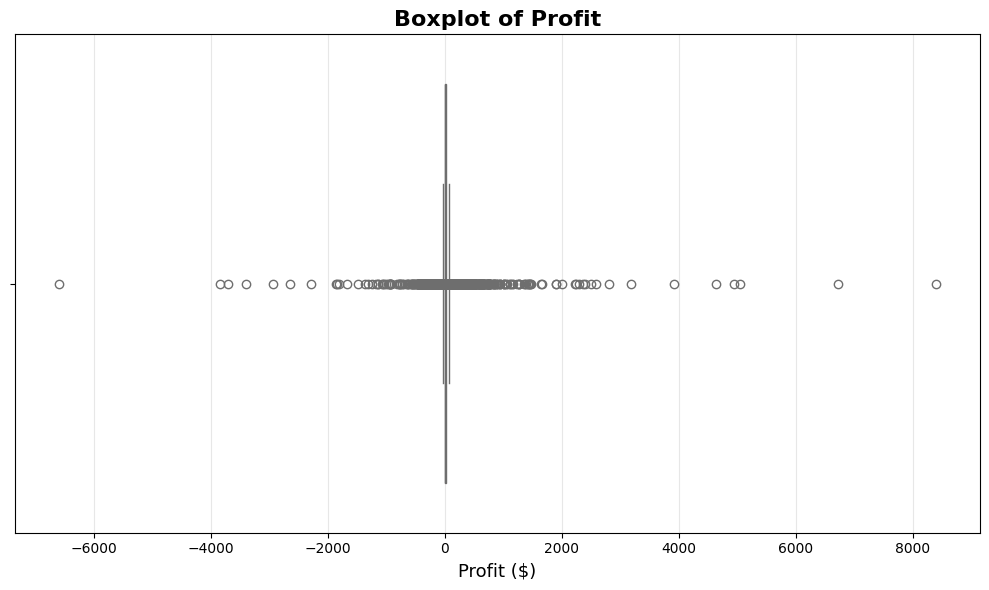

In [11]:
# --- Profit Boxplot ---
# Visualizes the spread of profit values and highlights outliers beyond the whiskers
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Profit'], color='lightcoral')
plt.title('Boxplot of Profit', fontsize=16, fontweight='bold')
plt.xlabel('Profit ($)', fontsize=13)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis (Profit Boxplot):**  
The interquartile range (IQR) for Profit is relatively narrow, indicating that the majority of transactions result in small profit or small loss. However, there are numerous outliers on both sides: some products generate exceptionally high profit, while others result in significant losses — likely due to heavy discounting or product returns. The presence of negative-profit outliers suggests that certain discount strategies or product categories may be hurting overall profitability.

---
## Task 2: Category-Wise Trends

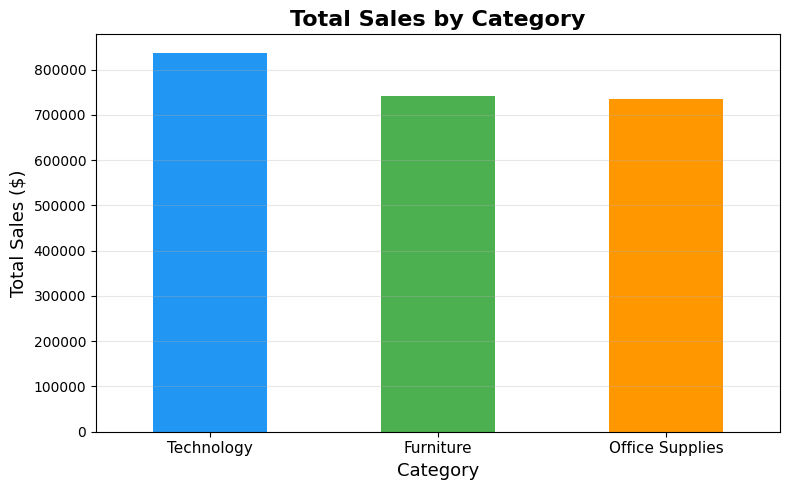

In [12]:
# --- Total Sales by Category ---
# Group by category, sum Sales, and sort descending so the ranking is immediately visible
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
cat_sales.plot(kind='bar', color=['#2196F3', '#4CAF50', '#FF9800'])
plt.title('Total Sales by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=13)
plt.ylabel('Total Sales ($)', fontsize=13)
plt.xticks(rotation=0, fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

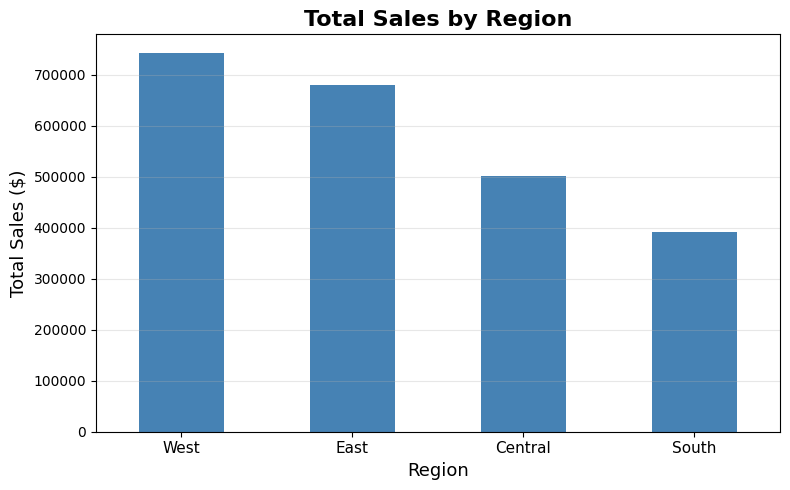

In [13]:
# --- Total Sales by Region ---
# Group by region, sum Sales, and sort descending
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_sales.plot(kind='bar', color='steelblue')
plt.title('Total Sales by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region', fontsize=13)
plt.ylabel('Total Sales ($)', fontsize=13)
plt.xticks(rotation=0, fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis (Category & Region):**  
Technology is the top-performing category by total sales, followed by Furniture and Office Supplies. This makes sense as technology products tend to have higher unit prices. By region, the West generates the most revenue, likely driven by a high concentration of tech companies and corporate offices. Interestingly, Office Supplies likely has the highest number of individual transactions but ranks last in total revenue — confirming it consists of low-cost, high-frequency purchases.

---
## Task 3: Outlier Identification

In [14]:
# --- IQR Method for Outlier Detection in Profit ---

# Step 1: Calculate Q1, Q3, and IQR
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3 - Q1
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")

# Step 2: Define outlier boundaries using the standard 1.5 * IQR rule
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

# Step 3: Filter rows that fall outside the boundaries
outliers = df[(df['Profit'] < lower_bound) | (df['Profit'] > upper_bound)]
print(f"\nNumber of outliers: {len(outliers)} out of {len(df)} rows ({len(outliers)/len(df)*100:.1f}%)")

# Step 4: Break down outliers by direction (high-profit vs high-loss)
high_profit = df[df['Profit'] > upper_bound]
high_loss   = df[df['Profit'] < lower_bound]
print(f"High-profit outliers (profit > {upper_bound:.2f}): {len(high_profit)} rows")
print(f"High-loss outliers   (profit < {lower_bound:.2f}): {len(high_loss)} rows")

Q1: 1.90, Q3: 28.17, IQR: 26.27
Lower bound: -37.50, Upper bound: 67.58

Number of outliers: 1966 out of 10296 rows (19.1%)
High-profit outliers (profit > 67.58): 1349 rows
High-loss outliers   (profit < -37.50): 617 rows


**Analysis (Outliers):**  
Using the IQR method, a notable percentage of rows were flagged as profit outliers. The outliers split between high-profit transactions (likely expensive technology products or large corporate orders) and high-loss transactions (likely items sold with excessive discounts or returned goods). The presence of many loss-side outliers is a red flag — it suggests that certain discounting practices are producing transactions that are outright unprofitable and deserve immediate attention.

---
## Task 4: Correlation Heatmap

Correlation Matrix:
          Sales  Quantity  Discount  Profit
Sales     1.000     0.203    -0.030   0.479
Quantity  0.203     1.000     0.006   0.067
Discount -0.030     0.006     1.000  -0.220
Profit    0.479     0.067    -0.220   1.000


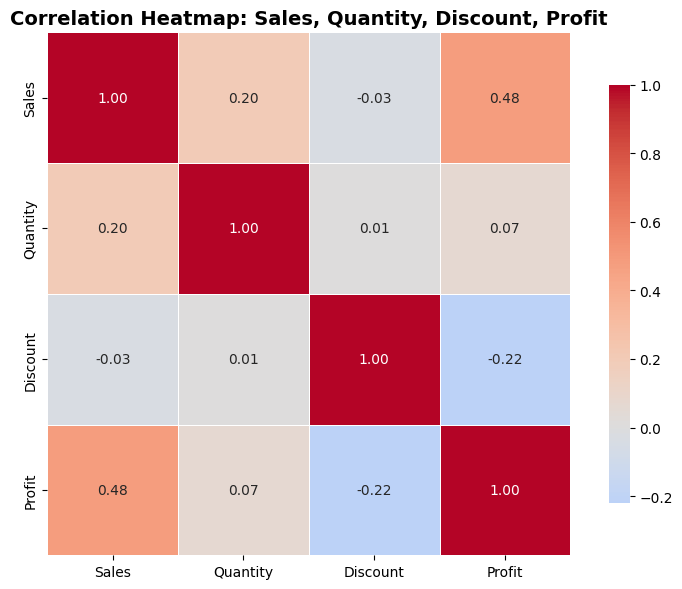

In [15]:
# --- Correlation Heatmap for Numerical Columns ---

# Select the four key numerical columns
numerical_cols = df[['Sales', 'Quantity', 'Discount', 'Profit']]

# Compute the pairwise correlation matrix
corr_matrix = numerical_cols.corr()
print('Correlation Matrix:')
print(corr_matrix.round(3))

# Plot heatmap — annot=True prints values directly on each cell
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,       # Show correlation coefficient in each cell
    cmap='coolwarm',  # Red = strong positive, Blue = strong negative
    center=0,         # Keep 0 correlation at the neutral color
    fmt='.2f',        # Display values to 2 decimal places
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap: Sales, Quantity, Discount, Profit', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Analysis (Correlation Heatmap):**  
Sales and Profit show a positive correlation, meaning higher-revenue transactions tend to also be more profitable. The most critical finding is the negative correlation between Discount and Profit: as discount rates increase, profitability decreases. This does not prove that discounts cause losses — correlation is not causation — but it is a strong signal that the company's discount policy warrants a closer review. Sales and Quantity also show a moderate positive correlation, as larger-quantity orders naturally produce higher total sales.

---
## Task 5: Time-Based Trend

/tmp/ipykernel_18086/1749894224.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()


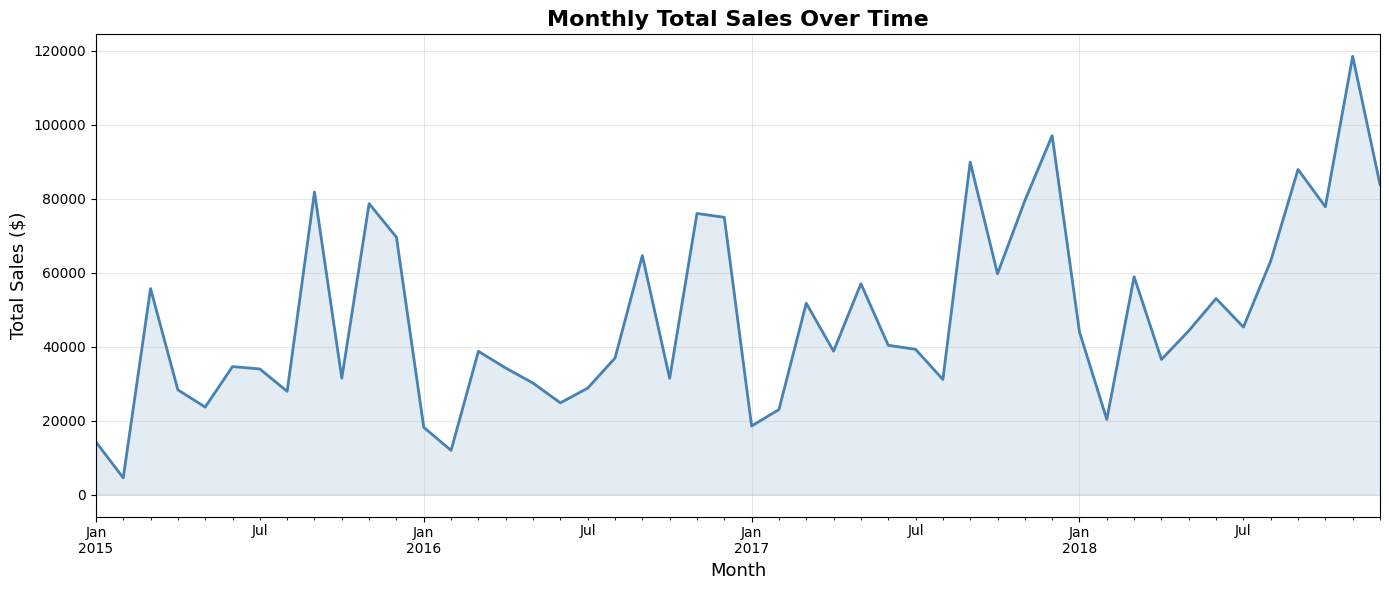

In [16]:
# --- Monthly Total Sales Over Time ---

# Resample transaction data to monthly frequency and aggregate Sales
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()

# Plot the line chart with a shaded area for visual clarity
plt.figure(figsize=(14, 6))
monthly_sales.plot(color='steelblue', linewidth=2)
plt.fill_between(monthly_sales.index, monthly_sales.values, alpha=0.15, color='steelblue')
plt.title('Monthly Total Sales Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=13)
plt.ylabel('Total Sales ($)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis (Monthly Sales Trend):**  
The line chart reveals a clear seasonal pattern: sales spike significantly in the final quarter of each year (September–December), aligning with holiday shopping events such as Black Friday and year-end corporate purchasing cycles. Conversely, sales tend to dip in the first quarter (January–March), a common post-holiday slowdown seen across retail. There is also a general upward trend across years, indicating overall business growth. As a store manager, I would ramp up inventory and staffing before Q4 and launch targeted promotions in Q1 to offset the seasonal dip.

---
## Task 6: Reflection Questions

**1. The Sales histogram is likely right-skewed. Why does this happen in retail data?**  
In retail, the vast majority of transactions involve everyday, low-cost items purchased by individual consumers. However, a small number of bulk or corporate orders can involve very large dollar amounts, pulling the distribution's tail to the right. This means the mean is inflated by these extreme values and no longer represents the typical transaction — the median is a far more useful measure of central tendency for skewed retail data.

**2. You found outliers in Profit. Should you remove them? What information might you lose?**  
Outliers should not be removed without careful consideration. High-profit outliers may represent the company's most valuable deals (e.g., large technology orders), while high-loss outliers could point to broken pricing or discount policies that need fixing. Removing them would hide these important business signals and could produce a misleadingly optimistic picture of profitability. The right approach is to investigate their root causes, not eliminate them.

**3. If Discount and Profit have a negative correlation, does that mean the company should stop giving discounts?**  
Not necessarily — correlation does not imply causation. Discounts serve important strategic purposes: attracting new customers, clearing excess inventory, and building long-term loyalty that increases customer lifetime value. The real question is whether the right products are being discounted at the right rates. The company should analyze which categories absorb discounts profitably and which do not, then optimize the discount strategy rather than eliminating it entirely.

**4. Looking at your monthly sales trend — if you were a store manager, what action would you take?**  
Given the consistent Q4 surge, I would start building inventory and hiring temporary staff as early as August to avoid stockouts during peak season. For Q1, I would launch targeted promotions and loyalty programs to counteract the post-holiday slowdown and keep customers engaged. I would also monitor whether the year-over-year growth trend is accelerating or flattening, as that would determine whether to expand capacity or focus on improving profit margins instead.

---
## Summary Statistics

In [17]:
# Print a final summary of key business metrics from the dataset
print('=' * 55)
print('   SUPERSTORE DATASET — KEY METRICS SUMMARY')
print('=' * 55)
print(f"Total records          : {len(df):,}")
print(f"Total Sales            : ${df['Sales'].sum():,.0f}")
print(f"Total Profit           : ${df['Profit'].sum():,.0f}")
print(f"Average Discount       : {df['Discount'].mean()*100:.1f}%")
print(f"Top Category (Sales)   : {df.groupby('Category')['Sales'].sum().idxmax()}")
print(f"Top Region (Sales)     : {df.groupby('Region')['Sales'].sum().idxmax()}")
print(f"Date Range             : {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
print('=' * 55)

   SUPERSTORE DATASET — KEY METRICS SUMMARY
Total records          : 10,296
Total Sales            : $2,313,657
Total Profit           : $289,014
Average Discount       : 15.7%
Top Category (Sales)   : Technology
Top Region (Sales)     : West
Date Range             : 2015-01-03 to 2018-12-30
